In [2]:
import os
import cv2
import numpy as np
import random


In [1]:

# 경로 설정
img_folder = 'train/rectangle_img'
ann_folder = 'train/rectangle_annotation'
output_img_path = 'output_images'
output_ann_path = 'output_annotations'

# 새 캔버스 크기 설정
canvas_width, canvas_height = 1900, 1080

# 출력 폴더 생성
os.makedirs(output_img_path, exist_ok=True)
os.makedirs(output_ann_path, exist_ok=True)

def load_annotations(txt_path):
    annotations = []
    with open(txt_path, 'r') as f:
        for line in f:
            cls, x_center, y_center, width, height = map(float, line.strip().split())
            annotations.append([cls, x_center, y_center, width, height])
    return annotations

def adjust_annotation(annotation, x_offset, y_offset, img_width, img_height, canvas_width, canvas_height):
    cls, x_center, y_center, width, height = annotation
    new_x_center = (x_center * img_width + x_offset) / canvas_width
    new_y_center = (y_center * img_height + y_offset) / canvas_height
    new_width = width * img_width / canvas_width
    new_height = height * img_height / canvas_height
    return [cls, new_x_center, new_y_center, new_width, new_height]

def check_overlap(rect, placed_rects):
    for placed in placed_rects:
        if (rect[0] < placed[0] + placed[2] and rect[0] + rect[2] > placed[0] and
            rect[1] < placed[1] + placed[3] and rect[1] + rect[3] > placed[1]):
            return True
    return False

# 모든 이미지와 라벨에 대해 처리
images = os.listdir(img_folder)
canvas = np.zeros((canvas_height, canvas_width, 3), dtype=np.uint8)
placed_rects = []
output_annotations = []

for _ in range(10):  # 예시로 무작위로 10개의 이미지를 선택
    img_file = random.choice(images)
    img_path = os.path.join(img_folder, img_file)
    img = cv2.imread(img_path)
    img_height, img_width = img.shape[:2]
    ann_file = os.path.join(ann_folder, os.path.splitext(img_file)[0] + '.txt')
    annotations = load_annotations(ann_file)

    # 이미지가 캔버스 안에 배치될 때까지 반복
    placed = False
    while not placed:
        x_offset = random.randint(0, canvas_width - img_width)
        y_offset = random.randint(0, canvas_height - img_height)
        
        rect = [x_offset, y_offset, img_width, img_height]
        
        if not check_overlap(rect, placed_rects):
            placed_rects.append(rect)
            placed = True

            # 새 좌표로 변환된 라벨 데이터
            new_annotations = [adjust_annotation(ann, x_offset, y_offset, img_width, img_height, canvas_width, canvas_height)
                               for ann in annotations]
            output_annotations.extend(new_annotations)

            # 캔버스에 이미지 배치
            canvas[y_offset:y_offset+img_height, x_offset:x_offset+img_width] = img

# 새로 생성된 이미지와 라벨 파일 저장
output_img_name = os.path.join(output_img_path, 'random_canvas.jpg')
output_ann_name = os.path.join(output_ann_path, 'random_canvas.txt')
cv2.imwrite(output_img_name, canvas)

with open(output_ann_name, 'w') as f:
    for ann in output_annotations:
        f.write(f"{int(ann[0])} {ann[1]:.6f} {ann[2]:.6f} {ann[3]:.6f} {ann[4]:.6f}\n")


In [3]:
def load_annotations(txt_path):
    annotations = []
    with open(txt_path, 'r') as f:
        for line in f:
            cls, x_center, y_center, width, height = map(float, line.strip().split())
            annotations.append([cls, x_center, y_center, width, height])
    return annotations

def adjust_annotation(annotation, x_offset, y_offset, img_width, img_height, canvas_width, canvas_height):
    cls, x_center, y_center, width, height = annotation
    new_x_center = (x_center * img_width + x_offset) / canvas_width
    new_y_center = (y_center * img_height + y_offset) / canvas_height
    new_width = width * img_width / canvas_width
    new_height = height * img_height / canvas_height
    return [cls, new_x_center, new_y_center, new_width, new_height]

def check_overlap(rect, placed_rects):
    for placed in placed_rects:
        if (rect[0] < placed[0] + placed[2] and rect[0] + rect[2] > placed[0] and
            rect[1] < placed[1] + placed[3] and rect[1] + rect[3] > placed[1]):
            return True
    return False


In [4]:

def multiple_img_aug(
        img_folder = 'train/rectangle_img',
        ann_folder = 'train/rectangle_annotation',
        output_img_path = 'train/combination_img',
        output_ann_path = 'train/combination_ann',
        canvas_width = 1900,
        canvas_height = 1080,
        img_num = 0
    ):

    # canvas_width, canvas_height = 1900, 1080

    os.makedirs(output_img_path, exist_ok=True)
    os.makedirs(output_ann_path, exist_ok=True)

    images = os.listdir(img_folder)
    canvas = np.zeros((canvas_height, canvas_width, 3), dtype=np.uint8)
    placed_rects = []
    output_annotations = []

    # random_count : 한 장의 이미지에 포함되는 약물의 수 1 ~ 10
    random_count = random.randint(1, 10)
    for _ in range(random_count):  
        img_file = random.choice(images)
        img_path = os.path.join(img_folder, img_file)
        img = cv2.imread(img_path)
        img_height, img_width = img.shape[:2]
        ann_file = os.path.join(ann_folder, os.path.splitext(img_file)[0] + '.txt')
        annotations = load_annotations(ann_file)

        placed = False
        while not placed:
            x_offset = random.randint(0, canvas_width - img_width)
            y_offset = random.randint(0, canvas_height - img_height)
            
            rect = [x_offset, y_offset, img_width, img_height]
            
            if not check_overlap(rect, placed_rects):
                placed_rects.append(rect)
                placed = True

                new_annotations = [adjust_annotation(ann, x_offset, y_offset, img_width, img_height, canvas_width, canvas_height)
                                for ann in annotations]
                output_annotations.extend(new_annotations)

                canvas[y_offset:y_offset+img_height, x_offset:x_offset+img_width] = img

    output_img_name = os.path.join(output_img_path, f'mul_aug_img_{img_num}.jpg')
    output_ann_name = os.path.join(output_ann_path, f'mul_aug_img_{img_num}.txt')
    cv2.imwrite(output_img_name, canvas)

    with open(output_ann_name, 'w') as f:
        for ann in output_annotations:
            f.write(f"{int(ann[0])} {ann[1]:.6f} {ann[2]:.6f} {ann[3]:.6f} {ann[4]:.6f}\n")


In [9]:
import cv2
import os

def draw_bboxes(image_path, bbox_path, output_path=None):
    # 이미지 읽기
    image = cv2.imread(image_path)
    h, w, _ = image.shape
    
    # 바운딩 박스 읽기 (YOLO 형식)
    with open(bbox_path, 'r') as file:
        lines = file.readlines()
        for line in lines:
            parts = line.strip().split()
            label = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            
            # YOLO 형식의 바운딩 박스를 픽셀 좌표로 변환
            x1 = int((x_center - width / 2) * w)
            y1 = int((y_center - height / 2) * h)
            x2 = int((x_center + width / 2) * w)
            y2 = int((y_center + height / 2) * h)
            
            # 바운딩 박스 그리기 (색상은 랜덤으로 지정)
            color = (0, 255, 0)  # 초록색 바운딩 박스
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
            cv2.putText(image, f'Label: {label}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    # 바운딩 박스가 그려진 이미지 저장 또는 출력
    if output_path:
        cv2.imwrite(output_path, image)
    else:
        cv2.imshow('Image with Bounding Boxes', image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

# 실제 YOLO 형식의 바운딩 박스 파일 경로
image_path = "train/combination_img/mul_aug_img_0.jpg"
bbox_path = 'train/combination_ann/mul_aug_img_0.txt'
output_image_path = 'merge_img_1.jpg'  # 결과 이미지를 저장할 경로

draw_bboxes(image_path, bbox_path, output_image_path)


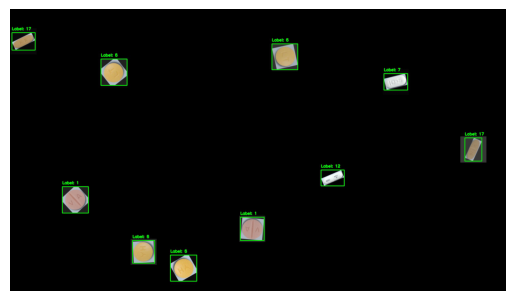

In [11]:
import cv2
import matplotlib.pyplot as plt

def show_image(image_path):
    # 이미지 읽기
    image = cv2.imread(image_path)
    
    # BGR을 RGB로 변환
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 이미지 표시
    plt.imshow(image_rgb)
    plt.axis('off')  # 축 숨기기
    plt.show()

image_path = 'merge_img.jpg'  # 확인할 이미지 경로
show_image(image_path)

In [6]:
"""
multiple_img_aug(
        img_folder = 'train/rectangle_img',
        ann_folder = 'train/rectangle_annotation',
        output_img_path = 'train/combination_img',
        output_ann_path = 'train/combination_ann',
        canvas_width = 1900,
        canvas_height = 1080,
        img_num = 0
    )
"""
# 2000 Photos & label img per class 
IMG_AUG_NUM = 20*10
for i in range(IMG_AUG_NUM):
    multiple_img_aug(
        img_folder = 'test/rectangle_img',
        ann_folder = 'test/rectangle_annotation',
        output_img_path = 'test/combination_img',
        output_ann_path = 'test/combination_ann',
        img_num=i)